In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('llm_final_prompt_no_response.csv')

In [10]:
df2 = pd.read_csv('llm_evaluation.csv')

In [11]:
df2.drop(columns='Time',inplace= True)

In [12]:
df2

,LLM,Prompt,Response,Originality,Usefulness,Divergence,Convergence
0,Perplexity,A1,Wouldn't use the data,2,2,1,3
1,Perplexity,B1,Wouldn't use the data,3,3,1,3
2,Perplexity,C1,Wouldn't use the data,3,3,1,3
3,Perplexity,A2,Would use this data,2,3,3,2
4,Perplexity,B2,Would use,2,3,3,1
5,Perplexity,C2,Would use,2,3,3,2
6,Perplexity,A3,Would use with changes,2,2,2,2
7,Perplexity,B3,Wouldn't use data,2,2,1,3
8,Perplexity,C3,Wouldn't use data,3,2,1,3
9,Gemini,A1,Wouldn't use the data,2,2,1,3


In [13]:
df3 = pd.read_csv('llm_prompts.csv')

In [14]:
df3.drop(columns='Time',inplace= True)

In [15]:
df3

,LLM,Prompt,Response,Originality,Usefulness,Divergence,Convergence
0,Perplexity,A1,Understand needs 25-30% (Build Prototype 30-35...,1,NaN,1,3
1,Gemini,A1,Gather Data 30%,2,NaN,1,1
2,Claude,A1,Build Prototype 35-40%,3,NaN,1,2
3,ChatGPT,A1,Understand Needs 30%,2,NaN,1,3
4,Perplexity,A2,Build prototype 40%,2,2.0,3,3
5,Gemini,A2,Build prototype 45%,2,3.0,3,3
6,Claude,A2,Build Prototype 40%,2,2.0,1,3
7,ChatGPT,A2,Understand needs 30%,2,1.0,1,1
8,Perplexity,A3,Build prototype 45%,2,2.0,3,3
9,Gemini,A3,Launch 35%,2,2.0,3,1


In [16]:
df.drop(columns='Time',inplace=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data_clean.csv')
labels = ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3']

for i, row in df.iterrows():
    model = row['LLM']
    div = [row['DivergenceA1'], row['DivergenceA2'], row['DivergenceA3'],
           row['DivergenceB1'], row['DivergenceB2'], row['DivergenceB3'],
           row['DivergenceC1'], row['DivergenceC2'], row['DivergenceC3']]

    fig, ax = plt.subplots(figsize=(8, 4))
    
    # --- ADD GRID HERE ---
    # linestyle='--' and alpha=0.7 make it subtle and professional
    ax.grid(True, linestyle='--', alpha=0.7, zorder=0) 
        
    # Plotting the data (zorder=3 puts it on top of the grid)
    ax.plot(labels, div, marker='o', zorder=3)
    
    ax.set_title(f'{model} - Divergence: Scenario 1')
    ax.set_ylim(0, 4)
    ax.set_yticks([0, 1, 2, 3])

    ax.axhline(y=1, color='red', linestyle='--', alpha=0.6, linewidth=1.5, zorder=4)
    ax.annotate('Baseline (Score 1)', 
                xy=(0, 1), xytext=(0.5, 0.4),
                arrowprops=dict(facecolor='black', arrowstyle='->', color='black'),
                fontsize=11, color='red', fontweight='bold')

    plt.tight_layout()
    
    # Save logic (Ensure these are indented inside the loop!)
    clean_name = str(model).replace(" ", "_").replace(".", "").replace("/", "_")
    filename = f"sc1_{clean_name}.png"
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"[{i+1}/{len(df)}] Generated and saved: {filename}")
    
    # Close to free up memory
    plt.close(fig)

C:\Users\killi\AppData\Local\Temp\ipykernel_1564\693882686.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.annotate('Baseline (Score 1)',


[1/4] Generated and saved: sc1_Perplexity.png
[2/4] Generated and saved: sc1_Gemini.png
[3/4] Generated and saved: sc1_Claude.png
[4/4] Generated and saved: sc1_ChatGPT.png


Saved: sc2_Perplexity_Divergence.png


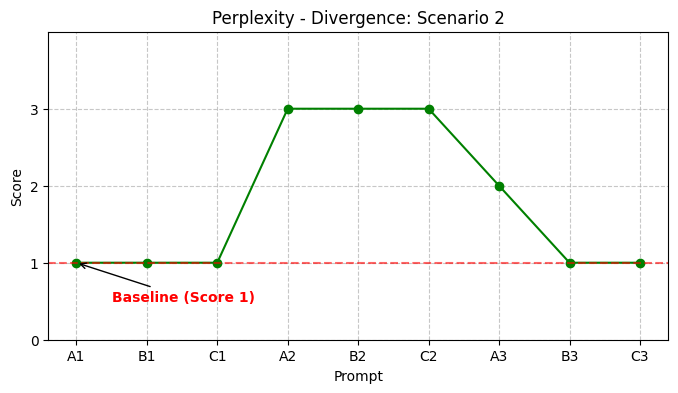

Saved: sc2_Gemini_Divergence.png


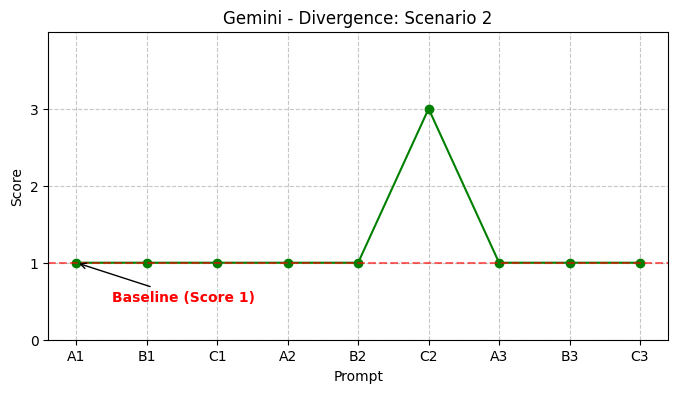

Saved: sc2_Claude_Divergence.png


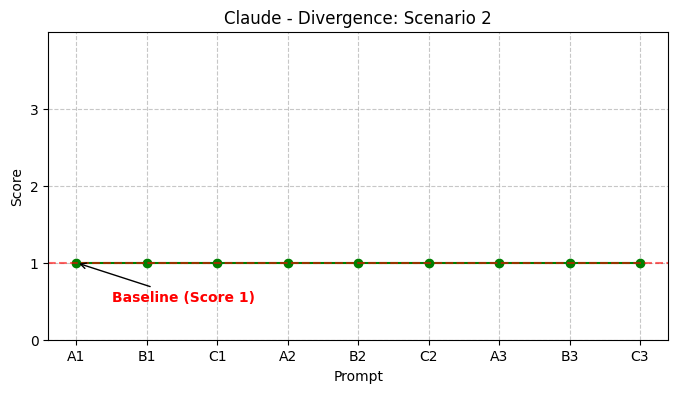

Saved: sc2_ChatGPT_Divergence.png


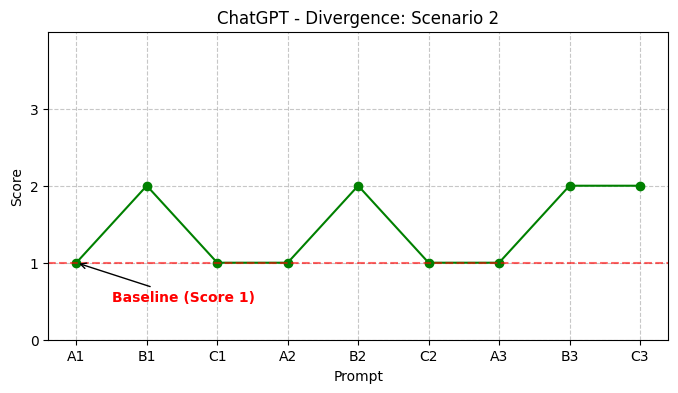

In [26]:
dfc = pd.DataFrame(df2)

# LLMs and metrics to plot
llms = ['Perplexity', 'Gemini', 'Claude','ChatGPT']
metrics = ['Divergence']

# Creating individual plots for each combination of LLM and metric
for llm in llms:
    for metric in metrics:
        # Filter the dataframe for the specific LLM
        subset = dfc[dfc['LLM'] == llm]
        
        # Create a new figure for each plot
        plt.figure(figsize=(8, 4))
        
        # Choose a color based on the metric
        line_color = 'green'
        
        # Plot the line
        plt.plot(subset['Prompt'], subset[metric], marker='o', linestyle='-', color=line_color)
        
        # Consistent integer range 0-3
        plt.ylim(0, 3.2)
        plt.yticks([0, 1, 2, 3])
        
        # ADD BASELINE ONLY FOR DIVERGENCE PLOTS
        if metric == 'Divergence':
            plt.axhline(y=1, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
            plt.annotate('Baseline (Score 1)', xy=(0, 1), xytext=(0.5, 0.5),
                         arrowprops=dict(facecolor='black', arrowstyle='->'),
                         fontsize=10, color='red', fontweight='bold')
            
        # Add labels and styling
        plt.title(f'{llm} - {metric}: Scenario 2')
        plt.xlabel('Prompt')
        plt.ylabel('Score')
        plt.ylim(0, 4)
        plt.grid(True, linestyle='--', alpha=0.7)
        
        filename = f"sc2_{llm}_{metric}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")

        plt.show()

Saved: sc3_Perplexity_Divergence.png


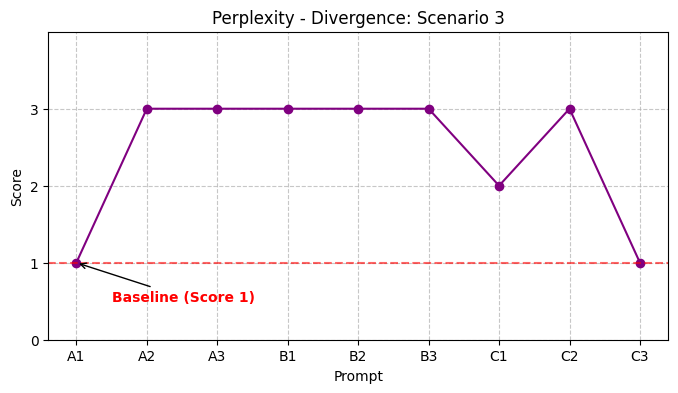

Saved: sc3_Gemini_Divergence.png


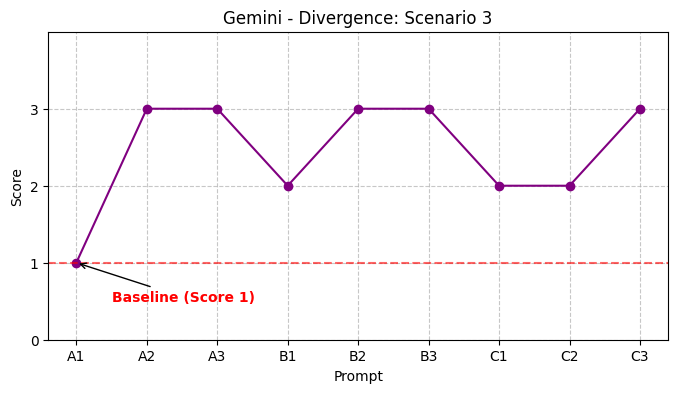

Saved: sc3_Claude_Divergence.png


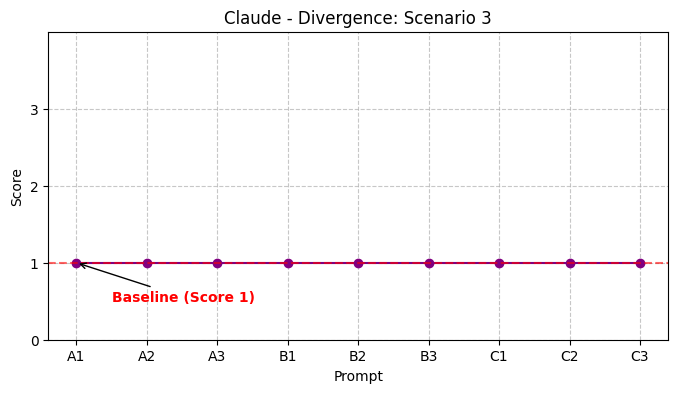

Saved: sc3_ChatGPT_Divergence.png


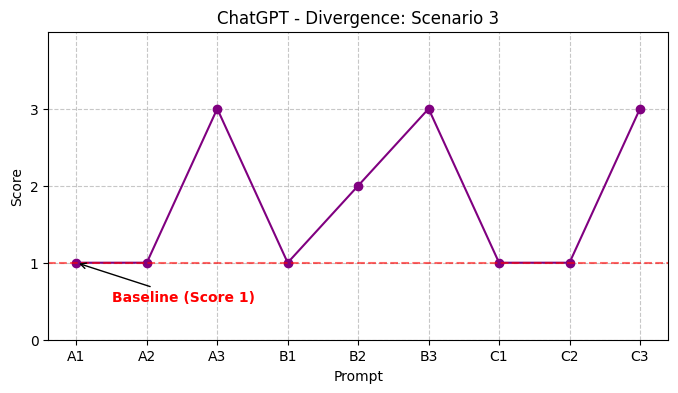

In [28]:
dfc = pd.DataFrame(df3)

# LLMs and metrics to plot
llms = ['Perplexity', 'Gemini', 'Claude','ChatGPT']
metrics = ['Divergence']

# Creating individual plots for each combination of LLM and metric
for llm in llms:
    for metric in metrics:
        # Filter the dataframe for the specific LLM
        subset = dfc[dfc['LLM'] == llm]
        
        # Create a new figure for each plot
        plt.figure(figsize=(8, 4))
        
        # Choose a color based on the metric
        line_color = 'purple'
        
        # Plot the line
        plt.plot(subset['Prompt'], subset[metric], marker='o', linestyle='-', color=line_color)
        
        # Consistent integer range 0-3
        plt.ylim(0, 3.2)
        plt.yticks([0, 1, 2, 3])
        
        # ADD BASELINE ONLY FOR DIVERGENCE PLOTS
        if metric == 'Divergence':
            plt.axhline(y=1, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
            plt.annotate('Baseline (Score 1)', xy=(0, 1), xytext=(0.5, 0.5),
                         arrowprops=dict(facecolor='black', arrowstyle='->'),
                         fontsize=10, color='red', fontweight='bold')
            
        # Add labels and styling
        plt.title(f'{llm} - {metric}: Scenario 3')
        plt.xlabel('Prompt')
        plt.ylabel('Score')
        plt.ylim(0, 4)
        plt.grid(True, linestyle='--', alpha=0.7)

        filename = f"sc3_{llm}_{metric}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")
        
        plt.show()